# Preprocessing — NSL-KDD Dataset

In this notebook, we prepare the NSL-KDD intrusion detection dataset before training machine learning models.

The objective is to:

- load the training and test datasets,
- inspect the data,
- convert the attack labels into a binary classification problem,
- encode categorical variables,
- scale numerical variables,
- save the processed datasets for the training notebook.

The final task is binary classification:

- `0` = normal traffic
- `1` = attack traffic

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

pd.set_option("display.max_columns", 200)

## 1. Define paths

We define the project paths.  
The notebook expects the raw NSL-KDD files to be in the same folder as the notebook.

The processed files will be saved in an `outputs/` folder.

In [19]:
PROJECT_ROOT = Path(".").resolve()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_FILE = PROJECT_ROOT / "KDDTrain+_20Percent.txt"
TEST_FILE = PROJECT_ROOT / "KDDTest+.txt"

# Compatibility if the files were downloaded or uploaded with "(1)" in the name
if not TRAIN_FILE.exists():
    TRAIN_FILE = PROJECT_ROOT / "KDDTrain+_20Percent(1).txt"

if not TEST_FILE.exists():
    TEST_FILE = PROJECT_ROOT / "KDDTest+(1).txt"

print("Project root:", PROJECT_ROOT)
print("Output directory:", OUTPUT_DIR)
print("Training file:", TRAIN_FILE)
print("Test file:", TEST_FILE)

Project root: C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack
Output directory: C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs
Training file: C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\KDDTrain+_20Percent.txt
Test file: C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\KDDTest+.txt


## 2. Define column names

The NSL-KDD text files do not contain headers in the original format.  
Therefore, we manually define the 43 columns:

- 41 input features,
- 1 attack label,
- 1 difficulty level.

In [20]:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "attack", "level"
]

print("Number of columns:", len(columns))

Number of columns: 43


## 3. Load the datasets

We load:

- `KDDTrain+_20Percent.txt` as the training set,
- `KDDTest+.txt` as the test set.

The training set is used to learn the preprocessing transformations.  
The test set is transformed using the same preprocessing fitted on the training set.

In [21]:
train_df = pd.read_csv(TRAIN_FILE, names=columns)
test_df = pd.read_csv(TEST_FILE, names=columns)

# Remove fake header row if the first row contains column names
if train_df.iloc[0]["duration"] == "duration":
    train_df = train_df.iloc[1:].reset_index(drop=True)

if test_df.iloc[0]["duration"] == "duration":
    test_df = test_df.iloc[1:].reset_index(drop=True)

# Clean column names
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

display(train_df.head())
display(test_df.head())
print(train_df.columns.tolist())

C:\Users\mbinmohdzaidi\AppData\Local\Temp\ipykernel_21796\552132186.py:1: DtypeWarning: Columns (0: duration, 1: src_bytes, 2: dst_bytes, 3: land, 4: wrong_fragment, 5: urgent, 6: hot, 7: num_failed_logins, 8: logged_in, 9: num_compromised, 10: root_shell, 11: su_attempted, 12: num_root, 13: num_file_creations, 14: num_shells, 15: num_access_files, 16: num_outbound_cmds, 17: is_host_login, 18: is_guest_login, 19: count, 20: srv_count, 21: serror_rate, 22: srv_serror_rate, 23: rerror_rate, 24: srv_rerror_rate, 25: same_srv_rate, 26: diff_srv_rate, 27: srv_diff_host_rate, 28: dst_host_count, 29: dst_host_srv_count, 30: dst_host_same_srv_rate, 31: dst_host_diff_srv_rate, 32: dst_host_same_src_port_rate, 33: dst_host_srv_diff_host_rate, 34: dst_host_serror_rate, 35: dst_host_srv_serror_rate, 36: dst_host_rerror_rate, 37: dst_host_srv_rerror_rate, 38: level) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(TRAIN_FILE, names=columns)


Training dataset shape: (25192, 43)
Test dataset shape: (22544, 43)


C:\Users\mbinmohdzaidi\AppData\Local\Temp\ipykernel_21796\552132186.py:2: DtypeWarning: Columns (0: duration, 1: src_bytes, 2: dst_bytes, 3: land, 4: wrong_fragment, 5: urgent, 6: hot, 7: num_failed_logins, 8: logged_in, 9: num_compromised, 10: root_shell, 11: su_attempted, 12: num_root, 13: num_file_creations, 14: num_shells, 15: num_access_files, 16: num_outbound_cmds, 17: is_host_login, 18: is_guest_login, 19: count, 20: srv_count, 21: serror_rate, 22: srv_serror_rate, 23: rerror_rate, 24: srv_rerror_rate, 25: same_srv_rate, 26: diff_srv_rate, 27: srv_diff_host_rate, 28: dst_host_count, 29: dst_host_srv_count, 30: dst_host_same_srv_rate, 31: dst_host_diff_srv_rate, 32: dst_host_same_src_port_rate, 33: dst_host_srv_diff_host_rate, 34: dst_host_serror_rate, 35: dst_host_srv_serror_rate, 36: dst_host_rerror_rate, 37: dst_host_srv_rerror_rate, 38: level) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(TEST_FILE, names=columns)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.00,0.00,0.00,0.00,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.00,0.00,0.00,0.00,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.00,1.00,0.00,0.00,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.20,0.20,0.00,0.00,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.00,0.00,0.00,0.00,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.00,0.00,1.00,1.00,0.04,0.06,0.00,255,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136,1,0.00,0.00,1.00,1.00,0.01,0.06,0.00,255,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.00,0.00,0.00,0.00,1.00,0.00,0.00,134,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,65,0.00,0.00,0.00,0.00,1.00,0.00,1.00,3,57,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.00,0.12,1.00,0.50,1.00,0.00,0.75,29,86,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,mscan,11


['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'level']


## 4. Basic data inspection

Before preprocessing, we inspect:

- column types,
- missing values,
- duplicated rows,
- first examples.

This step helps us verify if the dataset is clean enough to continue.

In [22]:
print("Training dataset information:")
train_df.info()

print("\nTest dataset information:")
test_df.info()

print("\nMissing values in training dataset:")
display(train_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing values in test dataset:")
display(test_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicated rows in training dataset:", train_df.duplicated().sum())
print("Duplicated rows in test dataset:", test_df.duplicated().sum())

Training dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   duration                     25192 non-null  object
 1   protocol_type                25192 non-null  str   
 2   service                      25192 non-null  str   
 3   flag                         25192 non-null  str   
 4   src_bytes                    25192 non-null  object
 5   dst_bytes                    25192 non-null  object
 6   land                         25192 non-null  object
 7   wrong_fragment               25192 non-null  object
 8   urgent                       25192 non-null  object
 9   hot                          25192 non-null  object
 10  num_failed_logins            25192 non-null  object
 11  logged_in                    25192 non-null  object
 12  num_compromised              25192 non-null  object
 13  root_shell  

duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64


Missing values in test dataset:


duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64


Duplicated rows in training dataset: 0
Duplicated rows in test dataset: 0


## 5. Attack label analysis

The original dataset contains many attack labels such as:

- `neptune`,
- `satan`,
- `ipsweep`,
- `portsweep`,
- `guess_passwd`,
- and others.

For this project, we first simplify the task into binary classification:

- normal traffic,
- attack traffic.

Attack label distribution in training set:


attack
normal             13449
neptune             8282
ipsweep              710
satan                691
portsweep            587
smurf                529
nmap                 301
back                 196
teardrop             188
warezclient          181
pod                   38
guess_passwd          10
warezmaster            7
buffer_overflow        6
imap                   5
rootkit                4
multihop               2
phf                    2
ftp_write              1
land                   1
Name: count, dtype: int64

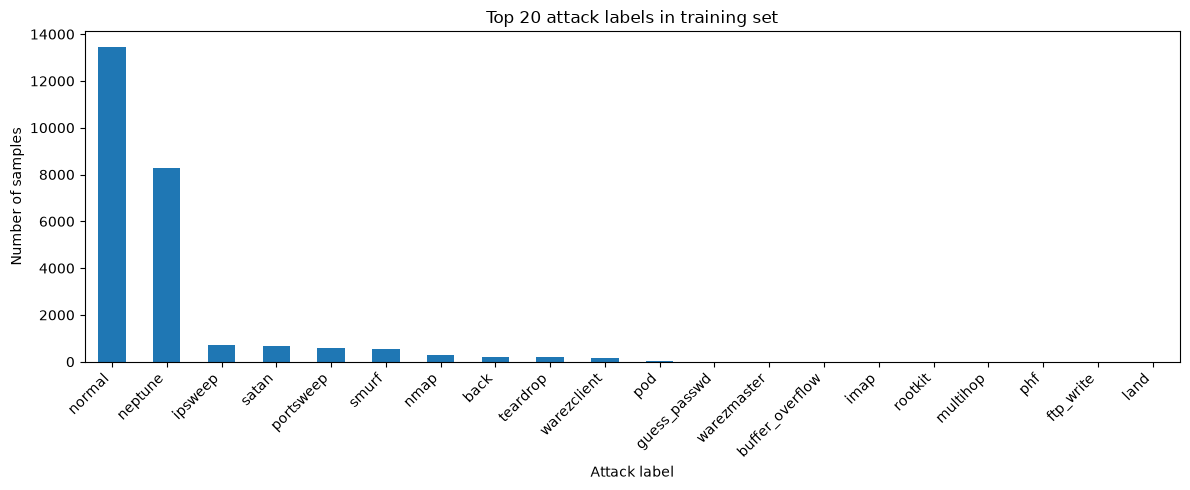

In [23]:
print("Attack label distribution in training set:")
display(train_df["attack"].value_counts().head(20))

plt.figure(figsize=(12, 5))
train_df["attack"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 attack labels in training set")
plt.xlabel("Attack label")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Convert target to binary classification

We create a new column called `target`.

The mapping is:

- `normal` → `0`
- every other attack label → `1`

This allows us to train binary classifiers that detect whether a connection is normal or malicious.

In [24]:
train_df["target"] = train_df["attack"].apply(lambda value: 0 if value == "normal" else 1)
test_df["target"] = test_df["attack"].apply(lambda value: 0 if value == "normal" else 1)

print("Binary target distribution in training set:")
display(train_df["target"].value_counts().rename(index={0: "normal", 1: "attack"}))

print("Binary target distribution in test set:")
display(test_df["target"].value_counts().rename(index={0: "normal", 1: "attack"}))

Binary target distribution in training set:


target
normal    13449
attack    11743
Name: count, dtype: int64

Binary target distribution in test set:


target
attack    12833
normal     9711
Name: count, dtype: int64

## 7. Separate features and target

We separate:

- `X_train` and `X_test`: input features,
- `y_train` and `y_test`: binary target.

We remove:

- `attack`, because it contains the original multiclass label,
- `level`, because it is a difficulty indicator and not an input feature for the classifier,
- `target`, because it is the label we want to predict.

In [25]:
X_train = train_df.drop(columns=["attack", "level", "target"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["attack", "level", "target"])
y_test = test_df["target"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (25192, 41)
X_test shape: (22544, 41)
y_train shape: (25192,)
y_test shape: (22544,)


## 8. Identify categorical and numerical features

The NSL-KDD dataset contains both categorical and numerical features.

Categorical features:

- `protocol_type`
- `service`
- `flag`

These must be encoded before being used by machine learning models.

All other features are numerical.

In [26]:
categorical_features = ["protocol_type", "service", "flag"]

numeric_features = [
    column for column in X_train.columns
    if column not in categorical_features
]

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numeric_features))
print("Numerical features:")
print(numeric_features)

Categorical features: ['protocol_type', 'service', 'flag']
Number of numerical features: 38
Numerical features:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## 9. Explore categorical features

We inspect the possible values of each categorical feature.

This is useful because OneHotEncoder will create one new binary column for each category.

In [27]:
for column in categorical_features:
    print(f"\nFeature: {column}")
    display(X_train[column].value_counts())


Feature: protocol_type


protocol_type
tcp     20526
udp      3011
icmp     1655
Name: count, dtype: int64


Feature: service


service
http         8003
private      4351
domain_u     1820
smtp         1449
ftp_data     1396
             ... 
urh_i           4
pm_dump         3
red_i           3
tim_i           2
http_8001       1
Name: count, Length: 66, dtype: int64


Feature: flag


flag
SF        14973
S0         7009
REJ        2216
RSTR        497
RSTO        304
S1           88
SH           43
RSTOS0       21
S2           21
S3           15
OTH           5
Name: count, dtype: int64

## 10. Explore numerical features

We display descriptive statistics for numerical features:

- mean,
- standard deviation,
- minimum,
- maximum,
- quartiles.

This helps detect very large scales and confirms why scaling is useful.

In [28]:
display(X_train[numeric_features].describe().T)

,count,unique,top,freq
duration,25192,819,0,15067
src_bytes,25192,2254,0,6480
dst_bytes,25192,4959,0,8872
land,25192,3,0,16381
wrong_fragment,25192,6,0,16242
urgent,25192,3,0,16382
hot,25192,36,0,16042
num_failed_logins,25192,7,0,16370
logged_in,25192,4,0,9945
num_compromised,25192,35,0,16214


## 11. Correlation analysis

We calculate the correlation matrix for numerical features and the target.

This can help identify features that are strongly related to the attack/normal label.

This step is exploratory only.  
We do not remove features automatically here.

Correlation matrix shape: (39, 39)


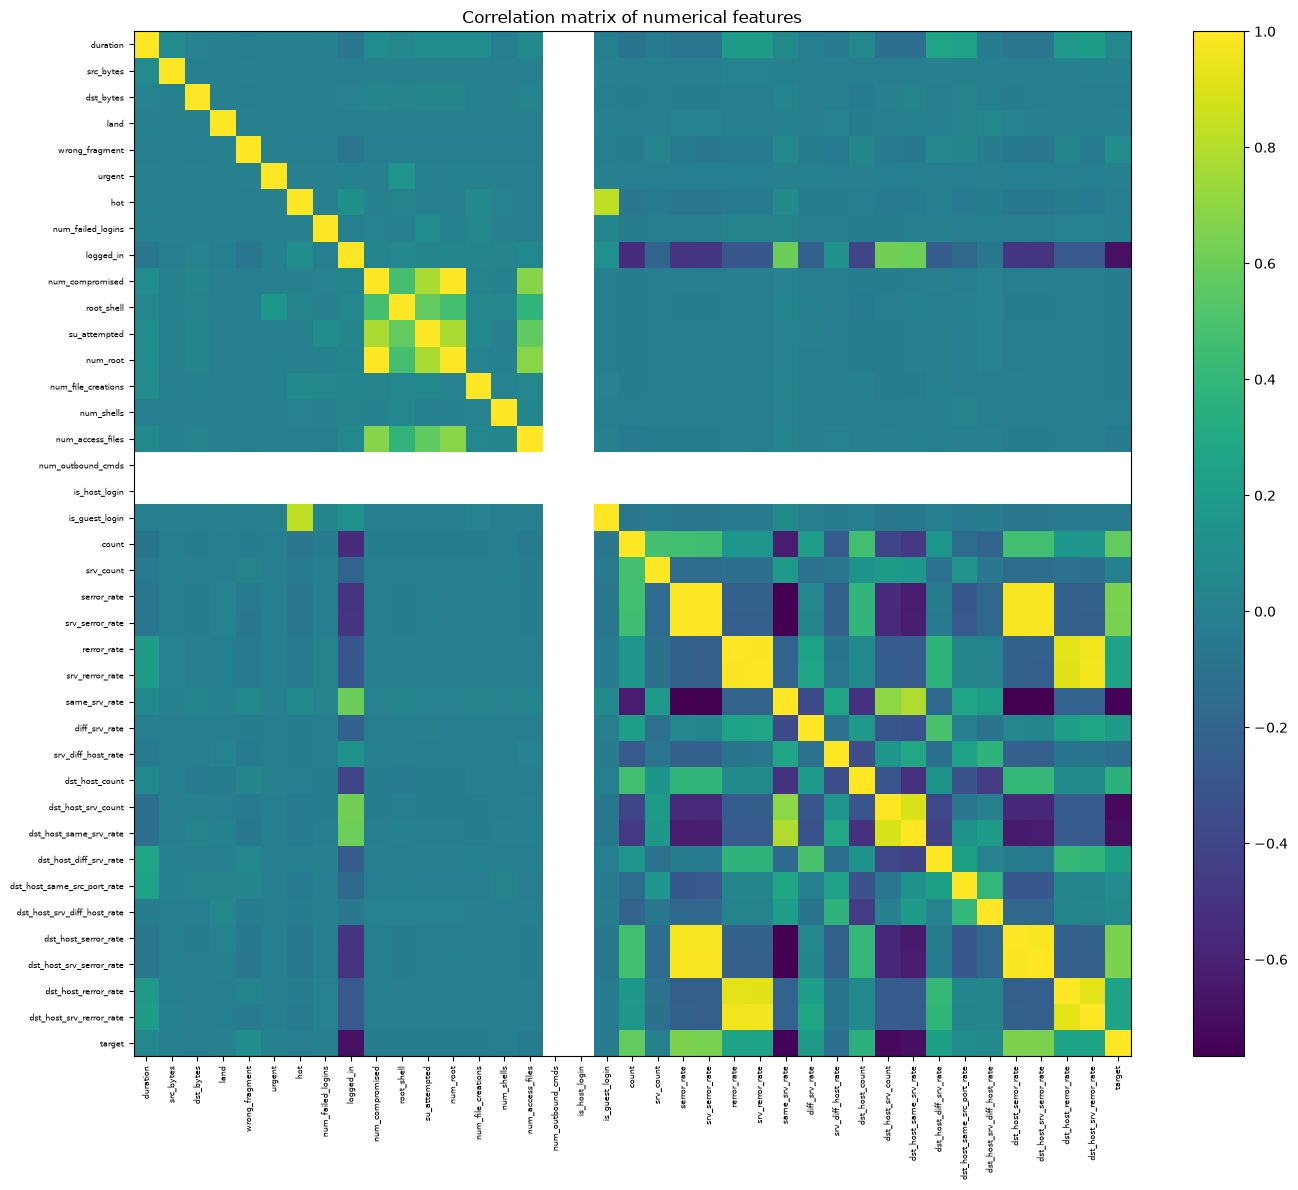

Top 15 features correlated with target:


same_srv_rate              -0.749237
dst_host_srv_count         -0.719292
dst_host_same_srv_rate     -0.692212
logged_in                  -0.688084
dst_host_srv_serror_rate    0.653759
dst_host_serror_rate        0.651050
serror_rate                 0.649952
srv_serror_rate             0.647817
count                       0.578790
dst_host_count              0.368828
dst_host_srv_rerror_rate    0.256999
rerror_rate                 0.256858
dst_host_rerror_rate        0.256312
srv_rerror_rate             0.256152
dst_host_diff_srv_rate      0.238170
Name: target, dtype: float64

In [29]:
# Make sure numerical columns and target are numeric
for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

train_df["target"] = pd.to_numeric(train_df["target"], errors="coerce")

# Create correlation matrix
correlation_df = train_df[numeric_features + ["target"]].corr()

print("Correlation matrix shape:", correlation_df.shape)

plt.figure(figsize=(14, 12))
plt.imshow(correlation_df, aspect="auto")
plt.colorbar()
plt.title("Correlation matrix of numerical features")
plt.xticks(
    ticks=np.arange(len(correlation_df.columns)),
    labels=correlation_df.columns,
    rotation=90,
    fontsize=6
)
plt.yticks(
    ticks=np.arange(len(correlation_df.index)),
    labels=correlation_df.index,
    fontsize=6
)
plt.tight_layout()
plt.show()

target_correlation = correlation_df["target"].drop("target").sort_values(
    key=abs,
    ascending=False
)

print("Top 15 features correlated with target:")
display(target_correlation.head(15))

## 12. Build preprocessing pipeline

We apply two transformations:

1. `StandardScaler` for numerical features  
   This standardizes numerical values so that models like KNN, Logistic Regression, and Neural Networks work better.

2. `OneHotEncoder` for categorical features  
   This converts text categories into numerical binary columns.

Important:  
The preprocessing pipeline is fitted only on the training set.  
Then the same transformation is applied to the test set.

In [30]:
try:
    categorical_transformer = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    categorical_transformer = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 13. Apply preprocessing

We fit the preprocessing pipeline on the training data and then transform both training and test data.

This prevents data leakage, because the test set is not used to learn scaling parameters or categories.

In [31]:
X_train_processed_array = preprocessor.fit_transform(X_train)
X_test_processed_array = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed_array.shape)
print("Processed test shape:", X_test_processed_array.shape)

Processed training shape: (25192, 118)
Processed test shape: (22544, 118)


## 14. Recover processed feature names

After OneHotEncoding, categorical columns are expanded into multiple binary columns.

For example:

- `protocol_type_tcp`
- `protocol_type_udp`
- `service_http`
- `flag_SF`

We recover these names so that feature importance plots are readable later in the training notebook.

In [32]:
onehot_encoder = preprocessor.named_transformers_["cat"]

categorical_feature_names = onehot_encoder.get_feature_names_out(categorical_features)

feature_names = list(numeric_features) + list(categorical_feature_names)

print("Number of final features:", len(feature_names))
print("First 20 feature names:")
print(feature_names[:20])

Number of final features: 118
First 20 feature names:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count']


## 15. Convert processed arrays to DataFrames

We convert the processed NumPy arrays back into pandas DataFrames.

This makes the saved files easier to read and easier to reuse in `training.ipynb`.

In [33]:
X_train_processed = pd.DataFrame(
    X_train_processed_array,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed_array,
    columns=feature_names
)

display(X_train_processed.head())

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_hostnames,service_http,service_http_443,service_http_8001,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.113551,-0.009889,-0.039310,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,-0.807626,-0.021873,-0.039377,-0.027665,-0.021724,-0.027808,-0.018905,-0.043917,0.0,0.0,-0.09599,-0.720244,-0.354628,-0.640142,-0.633978,-0.372186,-0.373098,0.772109,-0.349282,-0.373886,-0.328634,-0.813985,-0.779157,-0.280673,0.073120,-0.287993,-0.641804,-0.627365,-0.221668,-0.374281,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.113551,-0.010032,-0.039310,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,-0.807626,-0.021873,-0.039377,-0.027665,-0.021724,-0.027808,-0.018905,-0.043917,0.0,0.0,-0.09599,-0.624317,-0.368427,-0.640142,-0.633978,-0.372186,-0.373098,-1.320567,0.490836,-0.373886,0.732059,-1.030895,-1.157831,2.764403,2.375620,-0.287993,-0.641804,-0.627365,-0.385140,-0.374281,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.113551,-0.010093,-0.039310,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,-0.807626,-0.021873,-0.039377,-0.027665,-0.021724,-0.027808,-0.018905,-0.043917,0.0,0.0,-0.09599,0.334947,-0.299430,1.595477,1.600209,-0.372186,-0.373098,-1.388806,0.042773,-0.373886,0.732059,-0.804947,-0.935081,-0.173828,-0.478183,-0.287993,1.603834,1.614454,-0.385140,-0.374281,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.113551,-0.009996,0.052473,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,1.238197,-0.021873,-0.039377,-0.027665,-0.021724,-0.027808,-0.018905,-0.043917,0.0,0.0,-0.09599,-0.694082,-0.313230,-0.193018,-0.187141,-0.372186,-0.373098,0.772109,-0.3492

X_train_processed shape: (25192, 118)
X_test_processed shape: (22544, 118)


## 16. Save processed data

We save the processed datasets to the `outputs/` folder.

These files will be loaded by `training.ipynb`.

Saved files:

- `X_train_processed.csv`
- `X_test_processed.csv`
- `y_train.csv`
- `y_test.csv`
- `feature_names.csv`
- `preprocessor.pkl`

In [34]:
X_train_processed.to_csv(OUTPUT_DIR / "X_train_processed.csv", index=False)
X_test_processed.to_csv(OUTPUT_DIR / "X_test_processed.csv", index=False)

y_train.to_csv(OUTPUT_DIR / "y_train.csv", index=False)
y_test.to_csv(OUTPUT_DIR / "y_test.csv", index=False)

pd.Series(feature_names, name="feature").to_csv(
    OUTPUT_DIR / "feature_names.csv",
    index=False
)

joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.pkl")

print("Saved files:")
print("-", OUTPUT_DIR / "X_train_processed.csv")
print("-", OUTPUT_DIR / "X_test_processed.csv")
print("-", OUTPUT_DIR / "y_train.csv")
print("-", OUTPUT_DIR / "y_test.csv")
print("-", OUTPUT_DIR / "feature_names.csv")
print("-", OUTPUT_DIR / "preprocessor.pkl")

Saved files:
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\X_train_processed.csv
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\X_test_processed.csv
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\y_train.csv
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\y_test.csv
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\feature_names.csv
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\preprocessor.pkl


## 17. Conclusion

The preprocessing step is complete.

We now have:

- clean numerical features,
- encoded categorical features,
- scaled numerical features,
- binary labels for intrusion detection,
- processed files saved in the `outputs/` folder.

The next notebook, `training.ipynb`, can now load these files and compare different machine learning models.